# Model Explainability

## Ford Car Price Prediction — AutoPrice AI Pro

### Objective

Understand why the machine learning model makes its predictions.

### Explainability techniques

1. XGBoost Feature Importance
2. Permutation Importance
3. SHAP
4. Individual Prediction Explanation
5. Error Analysis

### Champion Model

Baseline XGBoost

RMSE = 1002.41
R² = 0.96

In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import joblib

import shap

In [2]:
xgb_pipeline = joblib.load(
    "../models/xgb_pipeline.pkl"
)

In [3]:
xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [4]:
best_model = xgb_pipeline

In [5]:
preprocessor = best_model.named_steps["preprocessor"]

In [6]:
xgb_model = best_model.named_steps["model"]

In [7]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age',
       'mileage_per_year'],
      dtype='str')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['model', 'transmission', 'fuelType', 'engine_category',
       'fuel_efficiency', 'tax_category'],
      dtype='str'))])


In [8]:
print(xgb_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)


In [9]:
df = pd.read_csv("../data/interim/featured_ford.csv")

In [10]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category,price_segment
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,9,1594.400000,small,medium,medium,Premium
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0,8,1009.222222,small,medium,medium,Premium
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0,9,1245.600000,small,medium,medium,Premium
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5,7,1307.500000,medium,medium,medium,Luxury
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,7,185.250000,small,medium,medium,Luxury


In [11]:
X = df.drop(["price" , "price_segment"] , axis=1)
y = df["price"]

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [14]:
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['model','year','transmission',...,'engine_category','fuel_efficiency', 'tax_category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This s

In [15]:
predictions = best_model.predict(X_test)

In [16]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

mae = mean_absolute_error(predictions,y_test)
rmse = root_mean_squared_error(predictions, y_test)
r2 = r2_score(predictions, y_test)

print("MAE" , mae)
print("RMSE" , rmse)
print("R2 Score" , r2)

MAE 813.7642822265625
RMSE 1172.1351318359375
R2 Score 0.9333620071411133


In [17]:
predictions[:5]

array([7766.0215, 9275.708 , 8345.467 , 6303.652 , 3103.821 ],
      dtype=float32)

In [18]:
feature_names = preprocessor.get_feature_names_out()

print("No of Features" , len(feature_names))

print("XGBBoost :" , xgb_model.n_features_in_)

No of Features 48
XGBBoost : 48


In [19]:

importance_values = xgb_model.feature_importances_

In [20]:
feature_importance = pd.DataFrame({
    "Feature" : feature_names,
    "Importance" : importance_values
})

In [21]:
feature_importance =feature_importance.sort_values(
    by="Importance",
    ascending= False
)

In [22]:
feature_importance.head(10)

,Feature,Importance
22,cat__model_ Mustang,0.158260
4,num__engineSize,0.120380
0,num__year,0.113622
40,cat__engine_category_medium,0.088538
5,num__car_age,0.078907
41,cat__engine_category_small,0.062323
19,cat__model_ Ka+,0.058194
20,cat__model_ Kuga,0.050997
12,cat__model_ Fiesta,0.037895
10,cat__model_ Edge,0.032572


In [23]:
top_features = feature_importance.head(15)

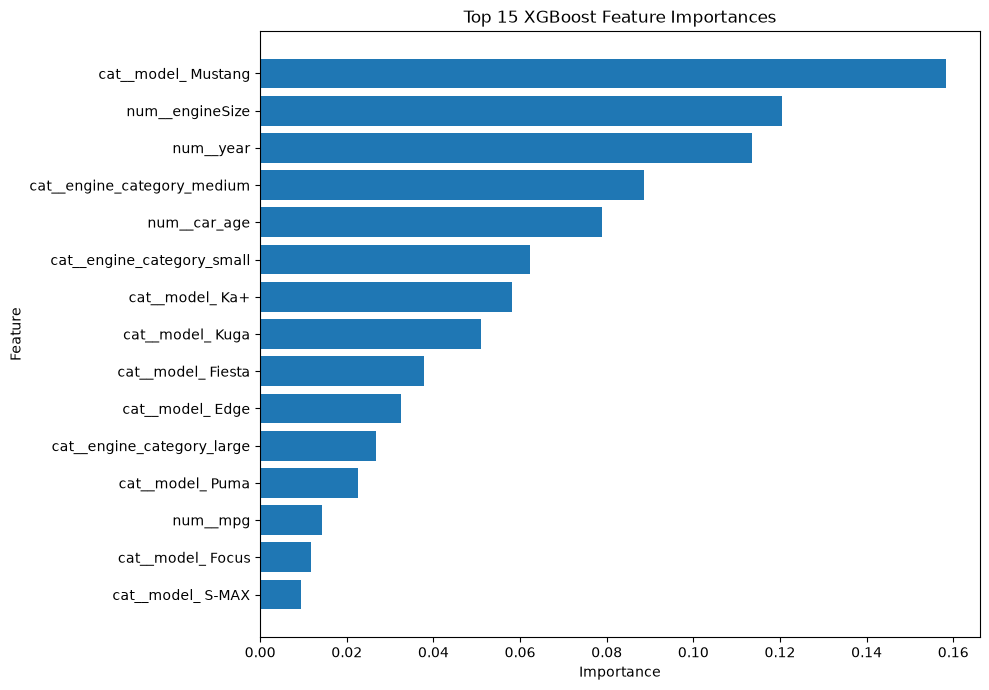

In [24]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()

plt.show()

In [25]:
feature_importance.head(20)

,Feature,Importance
22,cat__model_ Mustang,0.158260
4,num__engineSize,0.120380
0,num__year,0.113622
40,cat__engine_category_medium,0.088538
5,num__car_age,0.078907
41,cat__engine_category_small,0.062323
19,cat__model_ Ka+,0.058194
20,cat__model_ Kuga,0.050997
12,cat__model_ Fiesta,0.037895
10,cat__model_ Edge,0.032572


In [26]:
from sklearn.inspection import permutation_importance

In [27]:
permutation_result = permutation_importance(
    xgb_pipeline,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [28]:
permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": permutation_result.importances_mean
})

In [29]:
permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [30]:
permutation_importance_df.head(20)

,Feature,Importance
1,year,2028.431616
7,engineSize,1922.634302
0,model,847.637756
3,mileage,653.582715
6,mpg,520.041956
8,car_age,64.008887
2,transmission,52.078625
9,mileage_per_year,48.071313
5,tax,40.013196
4,fuelType,18.025659


In [31]:
top_permutation = permutation_importance_df.head(15)

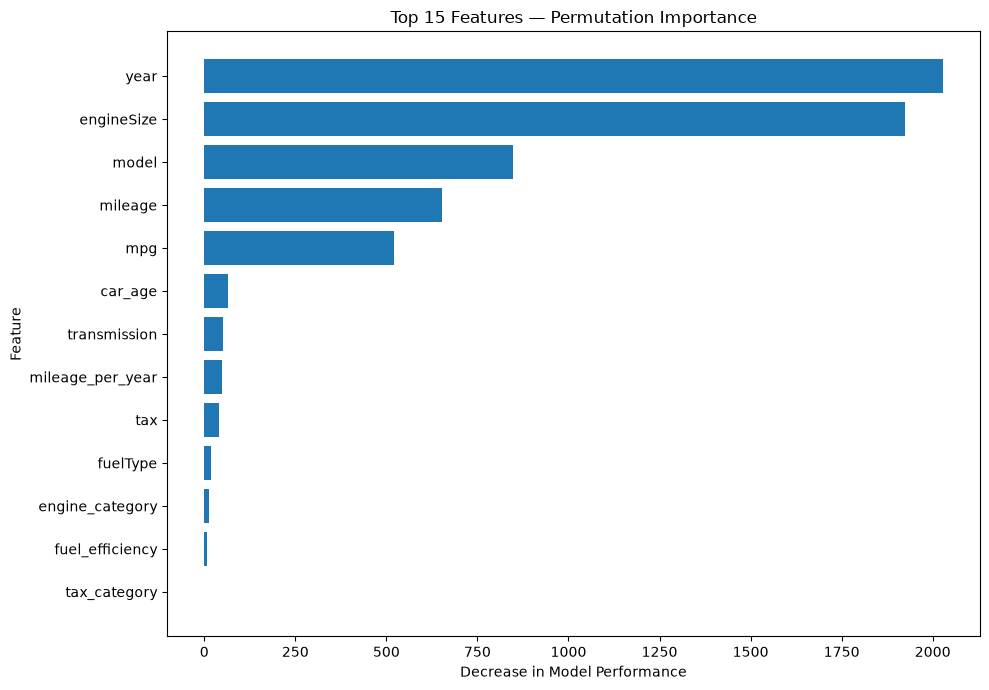

In [32]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation["Feature"],
    top_permutation["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Decrease in Model Performance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Permutation Importance")

plt.tight_layout()

plt.show()

# SHAP Explainability

SHAP (SHapley Additive exPlanations) explains how individual features contribute to model predictions.

Unlike basic feature importance, SHAP can show:

- Which features are important
- Whether a feature pushes the prediction higher or lower
- How strongly a feature affects an individual prediction

In [33]:
import shap
print(shap.__version__)

0.52.0


In [34]:
X_test_transformed = preprocessor.transform(X_test)

In [35]:
X_test_transformed.shape

(3594, 48)

In [36]:
type(X_test_transformed)

scipy.sparse._csr.csr_matrix

In [37]:
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

In [38]:
type(X_test_transformed)

numpy.ndarray

In [39]:
print("Data features :", X_test_transformed.shape[1])
print("Feature names :", len(feature_names))
print("Model features:", xgb_model.n_features_in_)

Data features : 48
Feature names : 48
Model features: 48


In [40]:
explainer = shap.TreeExplainer(xgb_model)

In [41]:
shap_values = explainer.shap_values(
    X_test_transformed
)

In [42]:
np.shape(shap_values)

(3594, 48)

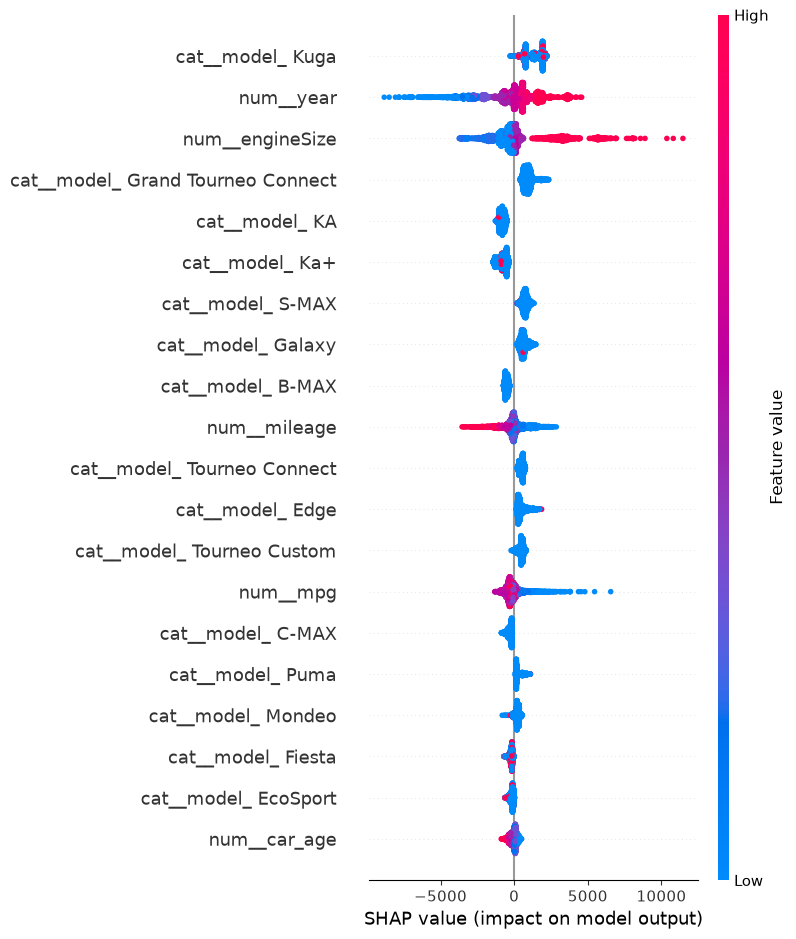

In [43]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

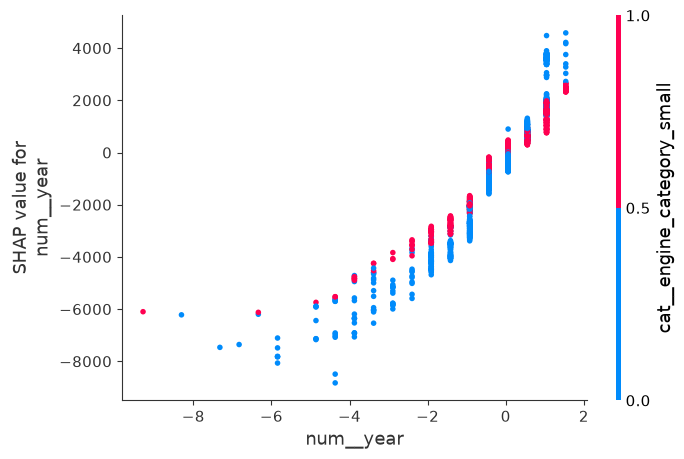

In [44]:
shap.dependence_plot(
    "num__year",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

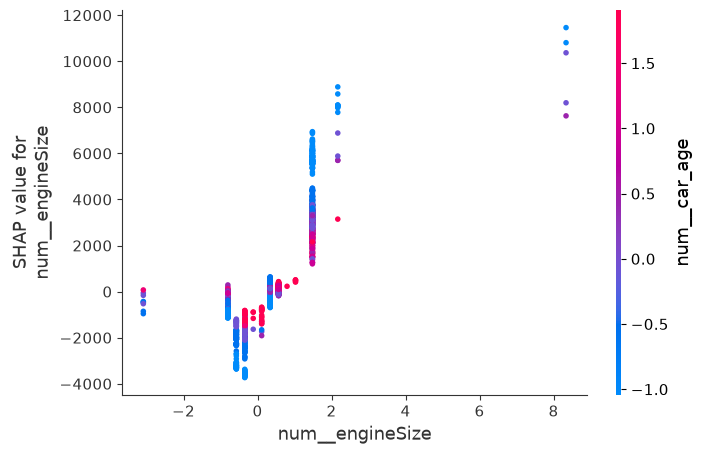

In [45]:
shap.dependence_plot(
    "num__engineSize",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

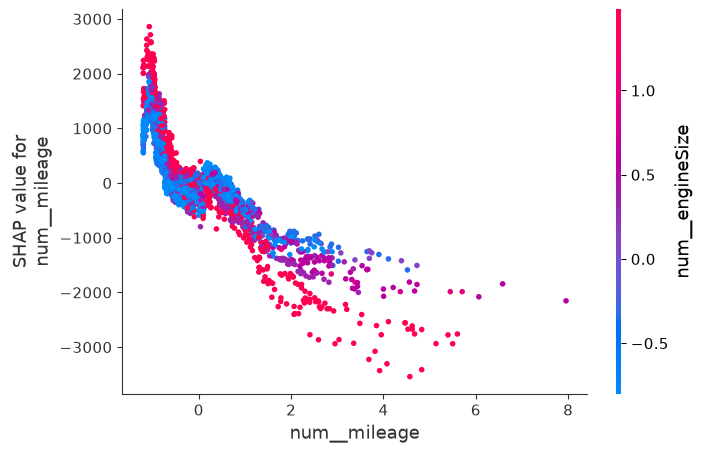

In [46]:
shap.dependence_plot(
    "num__mileage",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [47]:
sample_index = 0

In [48]:
sample = X_test.iloc[[sample_index]]

In [49]:
sample_prediction = xgb_pipeline.predict(sample)[0]

print("Predicted Price:", sample_prediction)

Predicted Price: 7766.0215


In [50]:
print("Actual Price:", y_test.iloc[sample_index])

Actual Price: 6995


In [51]:
sample_transformed = preprocessor.transform(sample)

In [52]:
sample_shap_values = explainer.shap_values(
    sample_transformed
)

In [53]:
sample_explanation = shap.Explanation(
    values=sample_shap_values[0],
    base_values=explainer.expected_value,
    data=sample_transformed[0],
    feature_names=feature_names
)

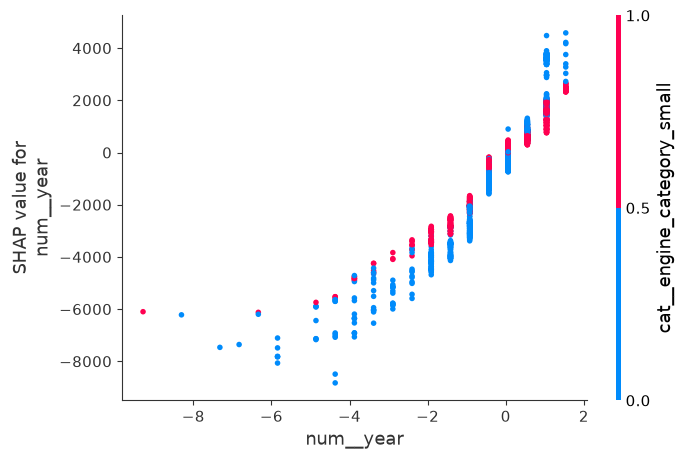

In [54]:
shap.dependence_plot(
    "num__year",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

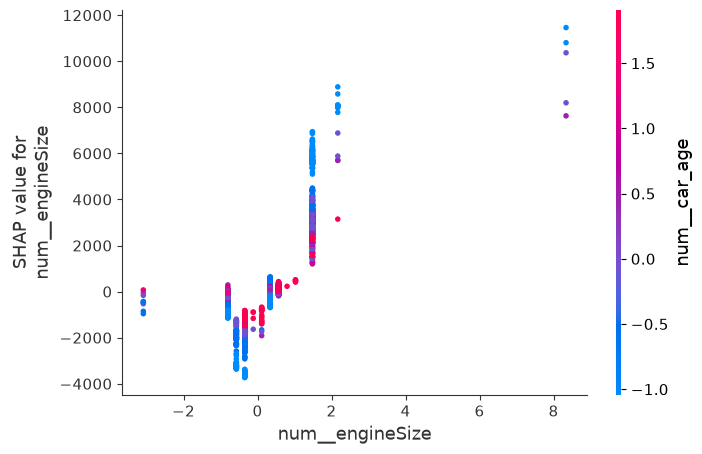

In [55]:
shap.dependence_plot(
    "num__engineSize",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

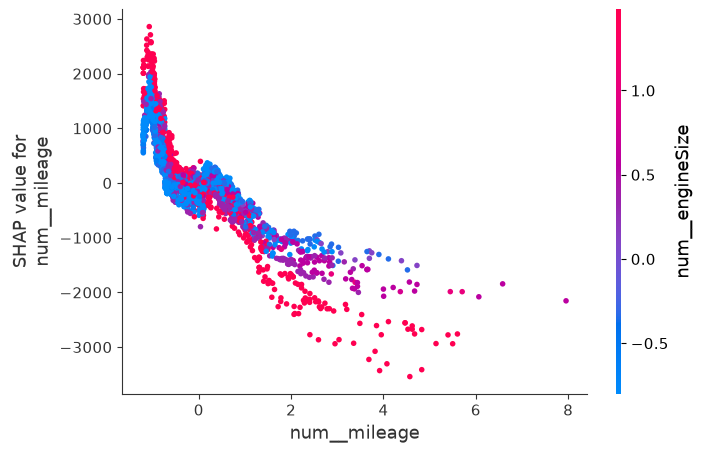

In [56]:
shap.dependence_plot(
    "num__mileage",
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [59]:
sample_index = 0
sample = X_test.iloc[[sample_index]]

actual_price = y_test.iloc[sample_index]
predicted_price = xgb_pipeline.predict(sample)[0]

print("Actual Price: ", actual_price)
print("Predicted Price: ", predicted_price)
print("Prediction Error: " , predicted_price-actual_price)

Actual Price:  6995
Predicted Price:  7766.0215
Prediction Error:  771.021484375


In [60]:
sample_transformed = preprocessor.transform(sample)

In [61]:
if hasattr(sample_transformed , "toarray" ):
    sample_transformed = sample_transformed.toarray()

In [62]:
sample_shap_values = explainer.shap_values(
    sample_transformed
)

In [63]:
sample_shap_values.shape

(1, 48)

In [64]:
sample_explanation = shap.Explanation(
    values= sample_shap_values[0],
    base_values=explainer.expected_value,
    data=sample_transformed[0],
    feature_names = feature_names
)

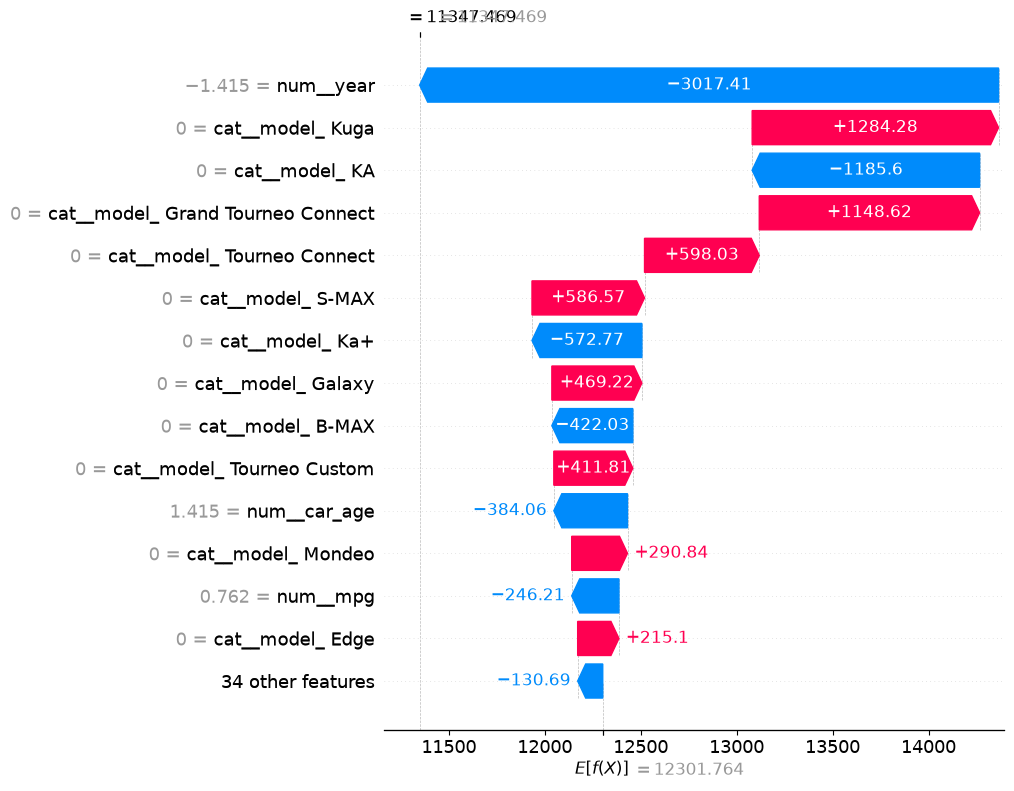

In [65]:
shap.plots.waterfall(
    sample_explanation,
    max_display = 15
)

# Error Analysis

Analyze where the champion XGBoost model performs well and where it makes large prediction errors.

In [66]:
test_predictions = xgb_pipeline.predict(X_test)

In [67]:
error_analysis = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted": test_predictions
})

In [68]:
error_analysis["Error"]=(
    error_analysis["Predicted"]- error_analysis["Actual"]
)

In [69]:
error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

In [70]:
error_analysis["Percentage_Error"] = (
    error_analysis["Absolute_Error"] / error_analysis["Actual"].abs()
)*100

In [71]:
error_analysis.head()

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
0,6995,7766.021484,771.021484,771.021484,11.022466
1,8999,9275.708008,276.708008,276.708008,3.074875
2,7998,8345.466797,347.466797,347.466797,4.344421
3,5491,6303.651855,812.651855,812.651855,14.799706
4,3790,3103.821045,-686.178955,686.178955,18.104986


## Actual vs Predicted Prices

This plot compares the actual vehicle prices with the prices predicted by the XGBoost model.

A perfect model would place every prediction on the diagonal line.

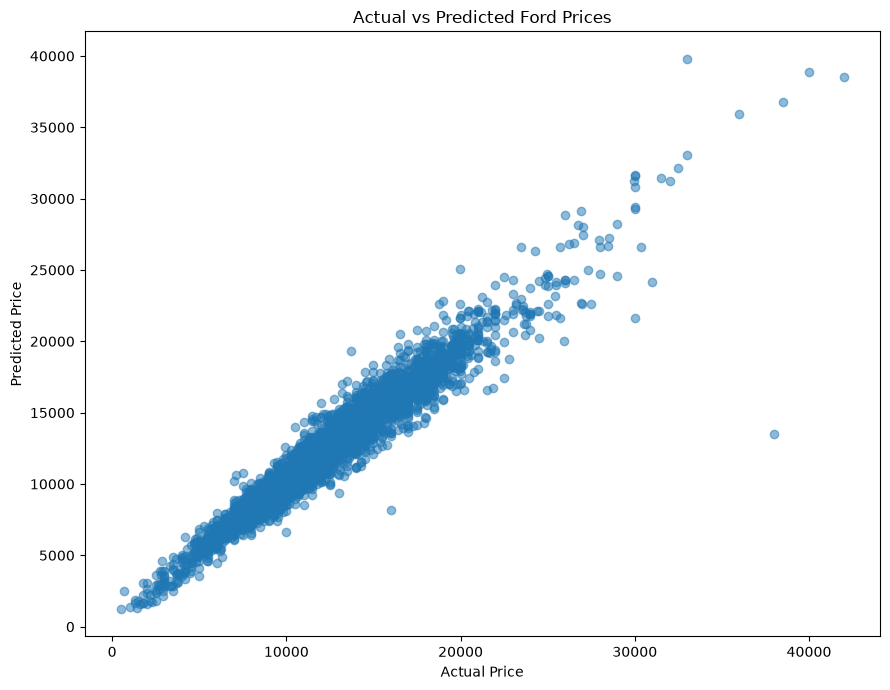

In [72]:
plt.figure(figsize=(9, 7))

plt.scatter(
    error_analysis["Actual"],
    error_analysis["Predicted"],
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Ford Prices")

plt.tight_layout()
plt.show()

In [73]:
min_price = min(
    error_analysis["Actual"].min(),
    error_analysis["Predicted"].min()
)

max_price = (
    error_analysis["Actual"].max(),
    error_analysis["Predicted"].max()
)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

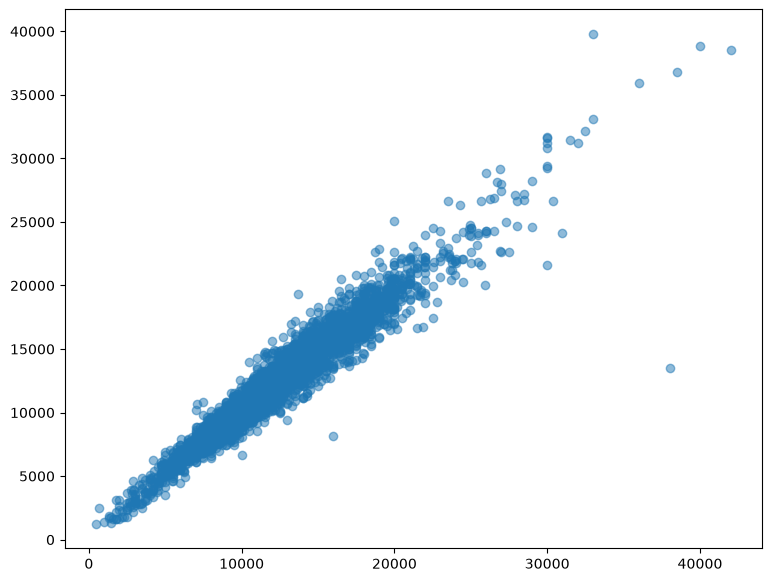

In [74]:
plt.figure(figsize=(9, 7))

plt.scatter(
    error_analysis["Actual"],
    error_analysis["Predicted"],
    alpha=0.5
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Ford Prices")

plt.tight_layout()
plt.show()

## Residual Analysis

Residuals represent the difference between predicted and actual prices.

Residual = Predicted Price - Actual Price

We use residual analysis to identify systematic prediction errors, outliers, and potential model weaknesses.

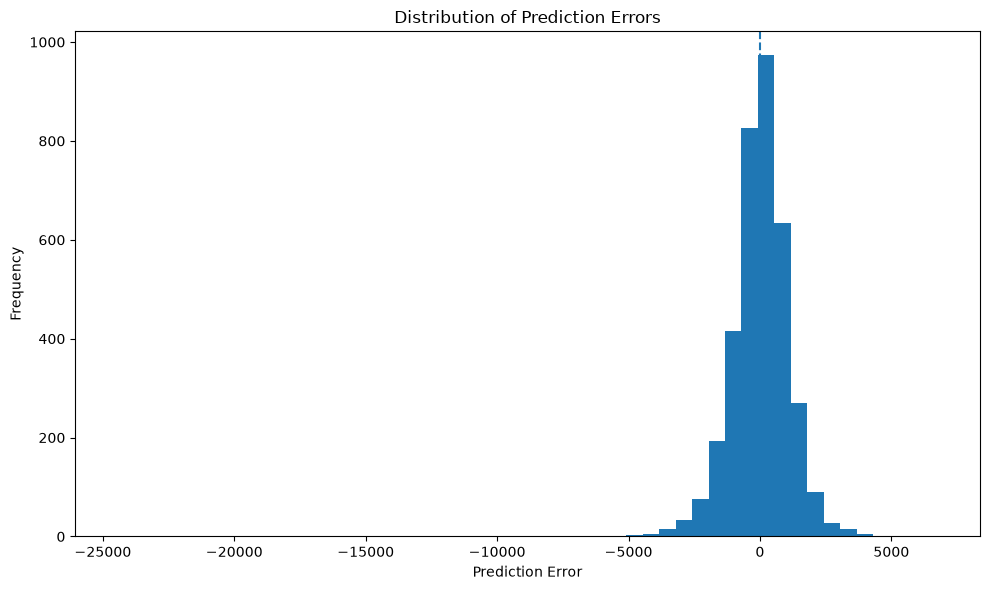

In [75]:
plt.figure(figsize=(10, 6))

plt.hist(
    error_analysis["Error"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [76]:
largest_errors  = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

In [77]:
largest_errors.head(20)

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
1202,38015,13526.987305,-24488.012695,24488.012695,64.416711
2174,30000,21605.957031,-8394.042969,8394.042969,27.980143
437,15999,8192.389648,-7806.610352,7806.610352,48.794364
463,30999,24138.072266,-6860.927734,6860.927734,22.132739
2691,32990,39798.566406,6808.566406,6808.566406,20.638273
782,25925,20041.806641,-5883.193359,5883.193359,22.693128
2698,13695,19294.373047,5599.373047,5599.373047,40.886258
1677,21865,16727.074219,-5137.925781,5137.925781,23.498403
337,19995,25050.490234,5055.490234,5055.490234,25.283772
300,22495,17444.253906,-5050.746094,5050.746094,22.452750


In [78]:
worst_index = largest_errors.index[0] 

In [79]:
print("Worst test index:" , worst_index)

Worst test index: 1202


In [87]:
largest_errors = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

largest_errors.head(20)

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
1202,38015,13526.987305,-24488.012695,24488.012695,64.416711
2174,30000,21605.957031,-8394.042969,8394.042969,27.980143
437,15999,8192.389648,-7806.610352,7806.610352,48.794364
463,30999,24138.072266,-6860.927734,6860.927734,22.132739
2691,32990,39798.566406,6808.566406,6808.566406,20.638273
782,25925,20041.806641,-5883.193359,5883.193359,22.693128
2698,13695,19294.373047,5599.373047,5599.373047,40.886258
1677,21865,16727.074219,-5137.925781,5137.925781,23.498403
337,19995,25050.490234,5055.490234,5055.490234,25.283772
300,22495,17444.253906,-5050.746094,5050.746094,22.452750


In [82]:
# worst_car = X_test.loc[[worst_index]]

print("Worst index:", worst_index)
print("X_test index:", X_test.index[:10])
print("Does it exist?", worst_index in X_test.index)

Worst index: 1202
X_test index: Index([17610, 7076, 1713, 1611, 16830, 14735, 322, 8164, 6822, 2133], dtype='int64')
Does it exist? False


In [90]:
print("largest_errors index:", largest_errors.index[0])
print("X_test index:", X_test.index[:10].tolist())

largest_errors index: 1202
X_test index: [17610, 7076, 1713, 1611, 16830, 14735, 322, 8164, 6822, 2133]


In [91]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

In [92]:
worst_position = largest_errors.index[0]

print("Worst test-set position:", worst_position)

worst_car = X_test.iloc[[worst_position]]

display(worst_car)

Worst test-set position: 1202


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category
1039,Focus,2017,Manual,197,Diesel,145,74.3,1.5,9,19.7,medium,high,medium


In [94]:
print("========== WORST PREDICTION ==========")

actual_price = y_test.iloc[worst_position]
predicted_price = xgb_pipeline.predict(worst_car)[0]

print("Actual Price    :", actual_price)
print("Predicted Price :", predicted_price)
print("Error           :", predicted_price - actual_price)

print(
    "Percentage Error:",
    largest_errors.iloc[0]["Percentage_Error"]
)

print("\n========== VEHICLE FEATURES ==========")

display(worst_car)

========== WORST PREDICTION ==========
Actual Price    : 38015
Predicted Price : 13526.987
Error           : -24488.0126953125
Percentage Error: 64.41671102278706

========== VEHICLE FEATURES ==========


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,mileage_per_year,engine_category,fuel_efficiency,tax_category
1039,Focus,2017,Manual,197,Diesel,145,74.3,1.5,9,19.7,medium,high,medium


In [95]:
focus_cars = X_test[
    X_test["model"] == worst_car["model"].iloc[0]
]

focus_cars[[
    "model",
    "year",
    "mileage",
    "engineSize",
    "transmission",
    "fuelType",
    "car_age",
    "mileage_per_year"
]].head(20)

,model,year,mileage,engineSize,transmission,fuelType,car_age,mileage_per_year
1713,Focus,2015,46155,1.6,Manual,Diesel,11,3846.250000
14735,Focus,2019,804,1.0,Manual,Petrol,7,100.500000
17032,Focus,2017,33173,1.0,Manual,Petrol,9,3317.300000
15370,Focus,2018,17989,1.5,Manual,Diesel,8,1998.777778
5181,Focus,2018,28068,2.0,Manual,Diesel,8,3118.666667
15058,Focus,2017,23300,1.0,Manual,Petrol,9,2330.000000
17373,Focus,2010,105000,1.6,Manual,Petrol,16,6176.470588
928,Focus,2017,17750,1.5,Manual,Diesel,9,1775.000000
14977,Focus,2019,5568,1.0,Manual,Petrol,7,696.000000
9571,Focus,2018,10755,1.5,Manual,Diesel,8,1195.000000


In [96]:
focus_cars["mileage"].describe()

count       869.000000
mean      24364.881473
std       20790.828134
min          10.000000
25%        9970.000000
50%       17819.000000
75%       33173.000000
max      177644.000000
Name: mileage, dtype: float64

In [97]:
similar_cars = X_test[
    (X_test["model"] == worst_car["model"].iloc[0]) &
    (X_test["year"] == worst_car["year"].iloc[0])
]

similar_cars[[
    "model",
    "year",
    "mileage",
    "engineSize",
    "transmission",
    "fuelType",
    "car_age",
    "mileage_per_year"
]]

,model,year,mileage,engineSize,transmission,fuelType,car_age,mileage_per_year
17032,Focus,2017,33173,1.0,Manual,Petrol,9,3317.3
15058,Focus,2017,23300,1.0,Manual,Petrol,9,2330.0
928,Focus,2017,17750,1.5,Manual,Diesel,9,1775.0
5083,Focus,2017,10843,2.0,Manual,Petrol,9,1084.3
5245,Focus,2017,42903,1.5,Manual,Diesel,9,4290.3
...,...,...,...,...,...,...,...,...
16551,Focus,2017,10760,1.5,Manual,Diesel,9,1076.0
487,Focus,2017,15121,1.0,Manual,Petrol,9,1512.1
14294,Focus,2017,10253,2.0,Manual,Diesel,9,1025.3
1957,Focus,2017,50875,1.5,Manual,Diesel,9,5087.5


In [98]:
similar_positions = similar_cars.index

In [99]:
similar_actual_prices = y_test.loc[similar_cars.index]

In [100]:
similar_actual_prices.describe()

count      232.000000
mean     12804.806034
std       3351.752316
min       8498.000000
25%      10779.250000
50%      11624.000000
75%      13825.000000
max      38015.000000
Name: price, dtype: float64

In [101]:
similar_train = X_train[
    (X_train["model"] == worst_car["model"].iloc[0]) &
    (X_train["year"] == worst_car["year"].iloc[0])
]

similar_train[[
    "model",
    "year",
    "mileage",
    "engineSize",
    "transmission",
    "fuelType",
    "car_age",
    "mileage_per_year"
]].head(20)

,model,year,mileage,engineSize,transmission,fuelType,car_age,mileage_per_year
8304,Focus,2017,22789,2.0,Manual,Petrol,9,2278.9
7858,Focus,2017,31070,1.5,Manual,Diesel,9,3107.0
6569,Focus,2017,30363,1.0,Manual,Petrol,9,3036.3
14020,Focus,2017,22000,1.0,Manual,Petrol,9,2200.0
2549,Focus,2017,11600,1.5,Manual,Petrol,9,1160.0
3376,Focus,2017,11045,1.0,Manual,Petrol,9,1104.5
4548,Focus,2017,14436,1.0,Manual,Petrol,9,1443.6
4983,Focus,2017,23708,2.0,Manual,Petrol,9,2370.8
8323,Focus,2017,13063,2.0,Manual,Petrol,9,1306.3
16011,Focus,2017,8974,1.0,Manual,Petrol,9,897.4


In [102]:
y_train.loc[similar_train.index].describe()

count      923.000000
mean     12496.731311
std       2900.499271
min       6995.000000
25%      10689.500000
50%      11599.000000
75%      12998.500000
max      32000.000000
Name: price, dtype: float64

In [103]:
worst_10 = largest_errors.head(10)[
    [
        "Actual",
        "Predicted",
        "Error",
        "Absolute_Error",
        "Percentage_Error"
    ]
]

worst_10

,Actual,Predicted,Error,Absolute_Error,Percentage_Error
1202,38015,13526.987305,-24488.012695,24488.012695,64.416711
2174,30000,21605.957031,-8394.042969,8394.042969,27.980143
437,15999,8192.389648,-7806.610352,7806.610352,48.794364
463,30999,24138.072266,-6860.927734,6860.927734,22.132739
2691,32990,39798.566406,6808.566406,6808.566406,20.638273
782,25925,20041.806641,-5883.193359,5883.193359,22.693128
2698,13695,19294.373047,5599.373047,5599.373047,40.886258
1677,21865,16727.074219,-5137.925781,5137.925781,23.498403
337,19995,25050.490234,5055.490234,5055.490234,25.283772
300,22495,17444.253906,-5050.746094,5050.746094,22.452750
